In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("bnpl_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50000, 9)


,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time


In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (50000, 9)

Missing values per column:
Transaction_ID       0
Customer_Age         0
Gender               0
Annual_Income        0
Credit_Score         0
Purchase_Category    0
BNPL_Provider        0
Purchase_Amount      0
Repayment_Status     0
dtype: int64

Duplicate rows: 0


In [4]:
target_col = "Repayment_Status"
print(df[target_col].value_counts())

Repayment_Status
Paid On Time    37612
Late Payment     8009
Defaulted        4379
Name: count, dtype: int64


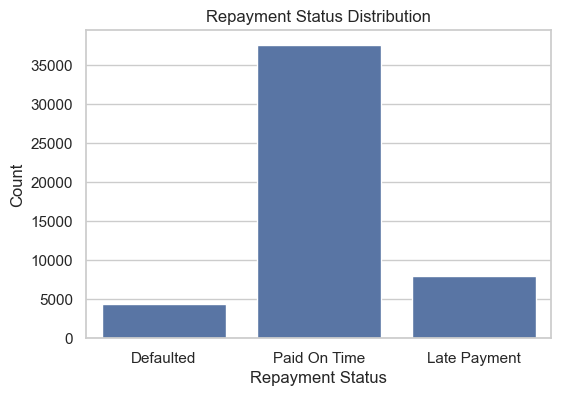

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Repayment Status Distribution")
plt.xlabel("Repayment Status")
plt.ylabel("Count")
plt.show()

In [6]:
print(df.dtypes)

Transaction_ID         str
Customer_Age         int64
Gender                 str
Annual_Income        int64
Credit_Score         int64
Purchase_Category      str
BNPL_Provider          str
Purchase_Amount      int64
Repayment_Status       str
dtype: object


In [7]:
df_fe = df.copy()

In [8]:
df_fe["income_to_purchase_ratio"] = df_fe["Annual_Income"] / (df_fe["Purchase_Amount"] + 1)
df_fe["income_per_age"] = df_fe["Annual_Income"] / df_fe["Customer_Age"]
df_fe["credit_utilization"] = df_fe["Purchase_Amount"] / (df_fe["Credit_Score"] + 1)

df_fe[["Annual_Income", "Purchase_Amount", "income_to_purchase_ratio", "income_per_age", "credit_utilization"]].head(10)

,Annual_Income,Purchase_Amount,income_to_purchase_ratio,income_per_age,credit_utilization
0,32293,249,129.172000,576.660714,0.703390
1,72774,188,385.047619,1582.043478,0.529577
2,82207,1610,51.028554,2568.968750,2.551506
3,92498,120,764.446281,1541.633333,0.254777
4,32060,1849,17.329730,1282.400000,3.675944
5,94833,1112,85.204852,2495.605263,1.425641
6,89772,418,214.252983,1603.071429,1.034653
7,82341,2117,38.876771,2287.250000,2.892077
8,80517,286,280.547038,2012.925000,0.426866
9,108929,244,444.608163,3890.321429,0.677778


In [9]:
df_fe["credit_score_tier"] = pd.cut(
    df_fe["Credit_Score"],
    bins=[0, 400, 600, 700, 850, np.inf],
    labels=["Very Poor", "Poor", "Fair", "Good", "Excellent"]
)

df_fe["age_credit_interaction"] = df_fe["Customer_Age"] * df_fe["Credit_Score"]

df_fe[["Credit_Score", "credit_score_tier", "age_credit_interaction"]].head(10)

,Credit_Score,credit_score_tier,age_credit_interaction
0,353,Very Poor,19768
1,354,Very Poor,16284
2,630,Fair,20160
3,470,Poor,28200
4,502,Poor,12550
5,779,Good,29602
6,403,Poor,22568
7,731,Good,26316
8,669,Fair,26760
9,359,Very Poor,10052


In [10]:
df_fe["purchase_tier"] = pd.cut(
    df_fe["Purchase_Amount"],
    bins=[0, 100, 250, 500, 1000, 2000, np.inf],
    labels=["Very Low", "Low", "Medium", "High", "Very High", "Premium"]
)

high_value_threshold = df_fe["Purchase_Amount"].quantile(0.75)
df_fe["is_high_value"] = (df_fe["Purchase_Amount"] > high_value_threshold).astype(int)

df_fe[["Purchase_Amount", "purchase_tier", "is_high_value"]].head(10)

,Purchase_Amount,purchase_tier,is_high_value
0,249,Low,0
1,188,Low,0
2,1610,Very High,1
3,120,Low,0
4,1849,Very High,1
5,1112,Very High,1
6,418,Medium,0
7,2117,Premium,1
8,286,Medium,0
9,244,Low,0


In [11]:
scaler = MinMaxScaler()
risk_features = scaler.fit_transform(
    df_fe[["Credit_Score", "Annual_Income", "Purchase_Amount"]]
)

df_fe["risk_score"] = (
    (1 - risk_features[:, 0]) * 0.5 +
    (1 - risk_features[:, 1]) * 0.3 +
    risk_features[:, 2] * 0.2
)

df_fe[["Credit_Score", "Annual_Income", "Purchase_Amount", "risk_score"]].head(10)

,Credit_Score,Annual_Income,Purchase_Amount,risk_score
0,353,32293,249,0.730225
1,354,72774,188,0.603773
2,630,82207,1610,0.419576
3,470,92498,120,0.434388
4,502,32060,1849,0.702641
5,779,94833,1112,0.212562
6,403,89772,418,0.523593
7,731,82341,2117,0.361227
8,669,80517,286,0.300238
9,359,108929,244,0.494512


In [12]:
print("Unique Purchase Categories:", df_fe["Purchase_Category"].nunique())
print(df_fe["Purchase_Category"].value_counts())

Unique Purchase Categories: 6
Purchase_Category
Travel              8401
Beauty              8381
Home & Furniture    8368
Fashion             8307
Electronics         8303
Groceries           8240
Name: count, dtype: int64


In [13]:
drop_cols = ["Transaction_ID"]

drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (50000, 15)
y shape: (50000,)


,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,income_to_purchase_ratio,income_per_age,credit_utilization,credit_score_tier,age_credit_interaction,purchase_tier,is_high_value,risk_score
0,56,Male,32293,353,Beauty,Sezzle,249,129.172000,576.660714,0.703390,Very Poor,19768,Low,0,0.730225
1,46,Male,72774,354,Groceries,Affirm,188,385.047619,1582.043478,0.529577,Very Poor,16284,Low,0,0.603773
2,32,Male,82207,630,Travel,Sezzle,1610,51.028554,2568.968750,2.551506,Fair,20160,Very High,1,0.419576
3,60,Male,92498,470,Fashion,Sezzle,120,764.446281,1541.633333,0.254777,Poor,28200,Low,0,0.434388
4,25,Male,32060,502,Travel,Klarna,1849,17.329730,1282.400000,3.675944,Poor,12550,Very High,1,0.702641


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (40000, 15)
Test size: (10000, 15)


In [15]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Gender', 'Purchase_Category', 'BNPL_Provider', 'credit_score_tier', 'purchase_tier']
Numeric columns: ['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount', 'income_to_purchase_ratio', 'income_per_age', 'credit_utilization', 'age_credit_interaction', 'is_high_value', 'risk_score']


C:\Users\mohal\AppData\Local\Temp\ipykernel_21052\1956993831.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [16]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

In [17]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

In [18]:
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [19]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7475

Classification Report:
              precision    recall  f1-score   support

   Defaulted       0.33      0.06      0.11       876
Late Payment       0.26      0.04      0.07      1602
Paid On Time       0.77      0.98      0.86      7522

    accuracy                           0.75     10000
   macro avg       0.45      0.36      0.35     10000
weighted avg       0.65      0.75      0.67     10000



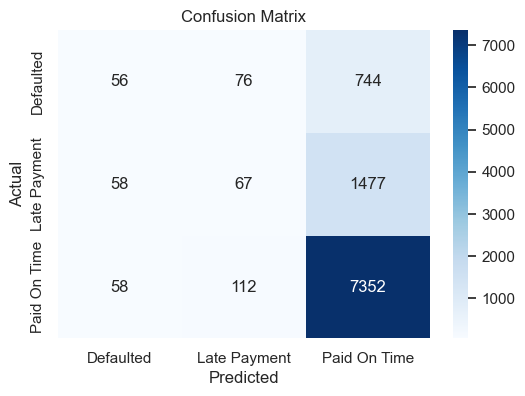

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
25,Credit_Score,0.112100
32,risk_score,0.105199
24,Annual_Income,0.100180
30,age_credit_interaction,0.092053
28,income_per_age,0.092037
27,income_to_purchase_ratio,0.086678
29,credit_utilization,0.085409
26,Purchase_Amount,0.082584
23,Customer_Age,0.070771
1,Gender_Male,0.012755


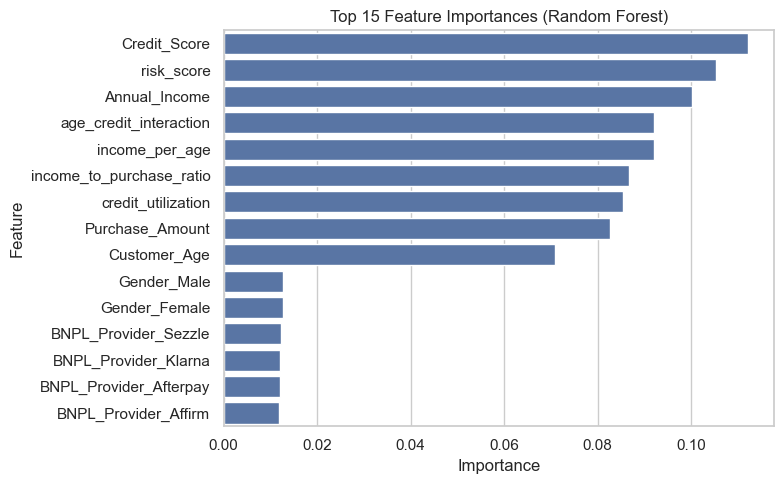

In [24]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [25]:
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))

Accuracy (with feature selection): 0.7489

Classification Report (with feature selection):
              precision    recall  f1-score   support

   Defaulted       0.29      0.06      0.10       876
Late Payment       0.28      0.04      0.08      1602
Paid On Time       0.77      0.98      0.86      7522

    accuracy                           0.75     10000
   macro avg       0.45      0.36      0.35     10000
weighted avg       0.65      0.75      0.67     10000



In [26]:
# Task 1: Create your own engineered feature
df_fe["debt_to_income_ratio"] = df_fe["Purchase_Amount"] / df_fe["Annual_Income"]
print("Task 1: Created debt_to_income_ratio feature")
print(df_fe[["Purchase_Amount", "Annual_Income", "debt_to_income_ratio"]].head())

# Task 2: Try different peak hour logic (not applicable for this dataset)
print("\nTask 2: For BNPL dataset, peak hours don't apply. Instead, try different credit score tiers.")

# Task 3: Test with different binning strategies
print("\nTask 3: Alternative credit score binning:")
df_fe["credit_score_tier_alt"] = pd.cut(
    df_fe["Credit_Score"],
    bins=[0, 500, 650, 800, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)
print(df_fe[["Credit_Score", "credit_score_tier_alt"]].head(10))

print("\nTask 4: Feature selection results shown above - compare accuracy with and without selection")

Task 1: Created debt_to_income_ratio feature
   Purchase_Amount  Annual_Income  debt_to_income_ratio
0              249          32293              0.007711
1              188          72774              0.002583
2             1610          82207              0.019585
3              120          92498              0.001297
4             1849          32060              0.057673

Task 2: For BNPL dataset, peak hours don't apply. Instead, try different credit score tiers.

Task 3: Alternative credit score binning:
   Credit_Score credit_score_tier_alt
0           353                   Low
1           354                   Low
2           630                Medium
3           470                   Low
4           502                Medium
5           779                  High
6           403                   Low
7           731                  High
8           669                  High
9           359                   Low

Task 4: Feature selection results shown above - compare accurac

In [28]:
print("=" * 60)
print("LAB COMPLETE: FEATURE ENGINEERING FOR BNPL DATASET")
print("=" * 60)
print("\nKey takeaways:")
print("1. Created income-based features (income_to_purchase_ratio, income_per_age)")
print("2. Created credit-based features (credit_score_tier, age_credit_interaction)")
print("3. Created amount-based features (purchase_tier, is_high_value)")
print("4. Created composite risk score feature")
print("5. Built Random Forest model with engineered features")
print("6. Analyzed feature importance to understand key predictors")


LAB COMPLETE: FEATURE ENGINEERING FOR BNPL DATASET

Key takeaways:
1. Created income-based features (income_to_purchase_ratio, income_per_age)
2. Created credit-based features (credit_score_tier, age_credit_interaction)
3. Created amount-based features (purchase_tier, is_high_value)
4. Created composite risk score feature
5. Built Random Forest model with engineered features
6. Analyzed feature importance to understand key predictors
